# Customer Churn Prediction Using Machine Learning

**Course:** Artificial Intelligence  
**Student:** Afaq Muzammil  
**Assignment:** Customer Churn Prediction Using Machine Learning  


### Objective
The aim of this assignment is to use customer data to predict whether a telecom customer will churn or stay.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

pd.set_option("display.max_columns", None)

DATA_FILE = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

if not Path(DATA_FILE).exists():
    csv_files = list(Path('.').glob('*.csv'))
    if csv_files:
        DATA_FILE = csv_files[0].name

if DATA_FILE.lower().endswith(".csv"):
    df = pd.read_csv(DATA_FILE)
else:
    df = pd.read_excel(DATA_FILE)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Loading and Understanding

The target variable is **Churn**. `Yes` means the customer left the telecom company and `No` means the customer stayed.

Important columns include `tenure` (months the customer has stayed), `MonthlyCharges` (monthly bill), `TotalCharges` (total amount charged), `Contract` (contract type), `InternetService`, `PaymentMethod`, and service-related columns such as `OnlineSecurity` and `TechSupport`.

In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
display(df.describe(include="all").T)

print("\nTarget distribution:")
display(df["Churn"].value_counts())
display(df["Churn"].value_counts(normalize=True).rename("Percentage"))


Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Target distribution:


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     0.73463
Yes    0.26537
Name: Percentage, dtype: float64

## 3. Data Preprocessing and Data Quality Checks

In [ ]:
print("Missing values:")
display(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

blank_total_charges = (df["TotalCharges"].astype(str).str.strip() == "").sum()
print("Blank TotalCharges values:", blank_total_charges)

print("Unique values in Churn:", df["Churn"].unique())


Missing values:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0
Blank TotalCharges values: 11
Unique values in Churn: ['No' 'Yes']


### Cleaning decisions

1. **`TotalCharges` conversion:** It is stored as text (`object`) even though it represents a numeric amount. It contains 11 blank values, so it is converted to numeric; blanks become `NaN`.
2. **Missing `TotalCharges`:** The 11 affected records are removed because `TotalCharges` is an important numeric variable and the missing values occur for customers with zero tenure.
3. **`customerID`:** This identifier is removed from model inputs because it uniquely identifies a customer and does not represent a useful customer behavior pattern.
4. **Duplicates:** No duplicate records were found.
5. **Categorical values:** Categorical features are one-hot encoded.
6. **Numeric values:** Numeric features are median-imputed through the preprocessing pipeline and standardized for Logistic Regression.


In [ ]:
data = df.copy()

data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
print("Missing TotalCharges after numeric conversion:", data["TotalCharges"].isna().sum())

data = data.dropna(subset=["TotalCharges"]).copy()
data = data.drop(columns=["customerID"])

# Feature engineering: group customers by length of tenure.
data["TenureGroup"] = pd.cut(
    data["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

print("Cleaned dataset shape:", data.shape)
display(data.head())


Missing TotalCharges after numeric conversion: 11
Cleaned dataset shape: (7032, 21)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 months
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-48 months
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 months
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 months
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 months


## 4. Exploratory Data Analysis

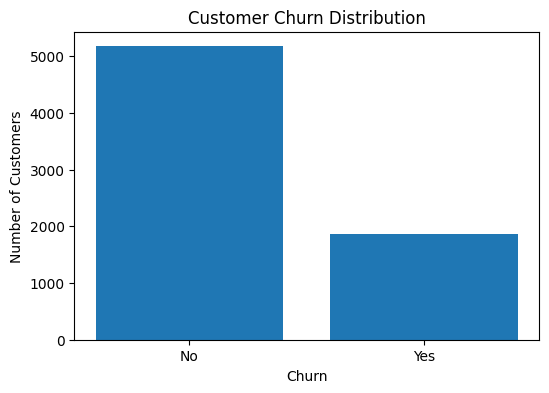

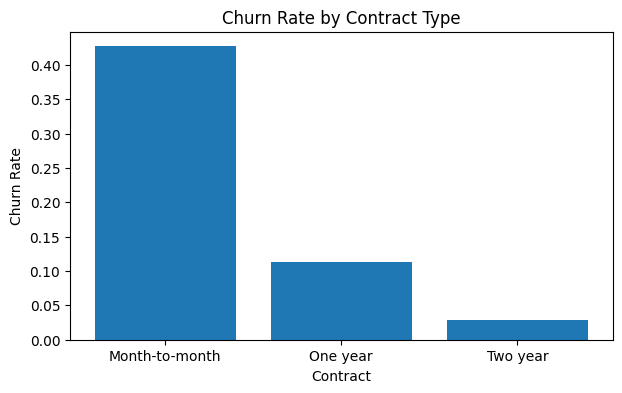

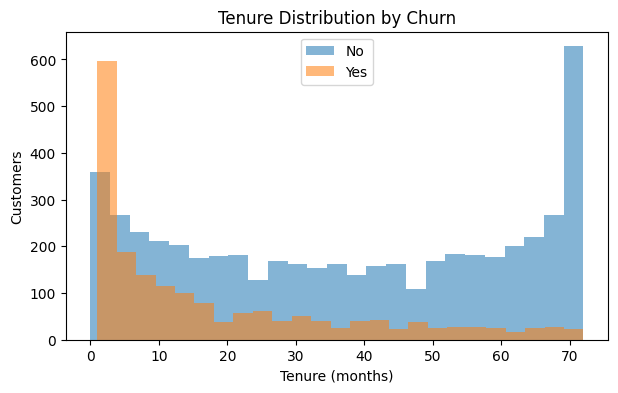

/tmp/ipykernel_486/625429312.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([monthly_no, monthly_yes], labels=["No", "Yes"])


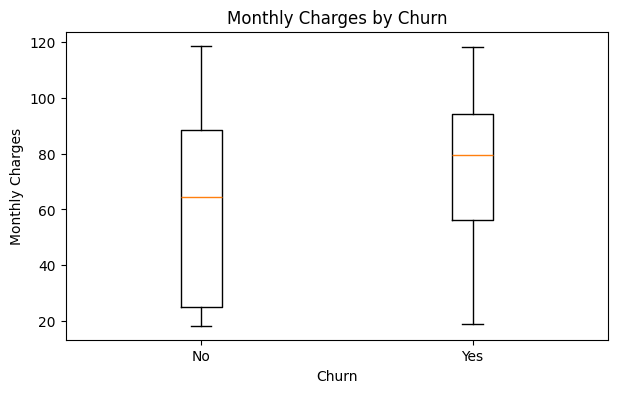

In [ ]:
# Churn distribution
churn_counts = df["Churn"].value_counts().reindex(["No", "Yes"])
plt.figure(figsize=(6,4))
plt.bar(churn_counts.index, churn_counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

# Churn rate by contract
contract_rate = pd.crosstab(df["Contract"], df["Churn"], normalize="index")["Yes"].sort_values(ascending=False)
plt.figure(figsize=(7,4))
plt.bar(contract_rate.index, contract_rate.values)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract")
plt.xticks(rotation=0)
plt.show()

# Tenure distribution
plt.figure(figsize=(7,4))
for label in ["No", "Yes"]:
    plt.hist(df.loc[df["Churn"] == label, "tenure"], bins=25, alpha=0.55, label=label)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Customers")
plt.legend()
plt.show()

# Monthly charges
monthly_no = df.loc[df["Churn"]=="No", "MonthlyCharges"]
monthly_yes = df.loc[df["Churn"]=="Yes", "MonthlyCharges"]
plt.figure(figsize=(7,4))
plt.boxplot([monthly_no, monthly_yes], labels=["No", "Yes"])
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()


### EDA observations

- Overall, the dataset contains more non-churned customers than churned customers.
- Month-to-month customers have a higher observed churn rate than one-year and two-year contract customers.
- Customers with shorter tenure appear more represented among churned customers.
- Monthly charges differ between churn groups, so billing level may contain predictive information.

These are observations from this dataset and do not by themselves prove causation.


## 5. Feature Engineering, Encoding, and Train/Test Split

In [ ]:
X = data.drop(columns=["Churn"])
y = data["Churn"].map({"No": 0, "Yes": 1})

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Input features (X):", X.shape)
print("Target (y):", y.shape)
print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Input features (X): (7032, 20)
Target (y): (7032,)
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']
Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Training rows: 5625
Testing rows: 1407


In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


## 6. Train Two Classification Models

In [ ]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

logistic_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("Both models trained successfully.")


Both models trained successfully.


## 7. Model Evaluation

In [ ]:
def evaluate_model(name, model):
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)
    cm = confusion_matrix(y_test, predictions)

    print(f"### {name}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, predictions, target_names=["No Churn", "Churn"], zero_division=0))
    return [accuracy, precision, recall, f1], cm

log_metrics, log_cm = evaluate_model("Logistic Regression", logistic_model)
rf_metrics, rf_cm = evaluate_model("Random Forest", random_forest_model)

results = pd.DataFrame(
    [log_metrics, rf_metrics],
    columns=["Accuracy", "Precision", "Recall", "F1-Score"],
    index=["Logistic Regression", "Random Forest"]
)
display(results.round(4))


### Logistic Regression
Accuracy : 0.7939
Precision: 0.6355
Recall   : 0.5267
F1-Score : 0.5760

Confusion Matrix:
[[920 113]
 [177 197]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1033
       Churn       0.64      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407

### Random Forest
Accuracy : 0.7846
Precision: 0.6220
Recall   : 0.4840
F1-Score : 0.5444

Confusion Matrix:
[[923 110]
 [193 181]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407



,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.7939,0.6355,0.5267,0.5760
Random Forest,0.7846,0.6220,0.4840,0.5444


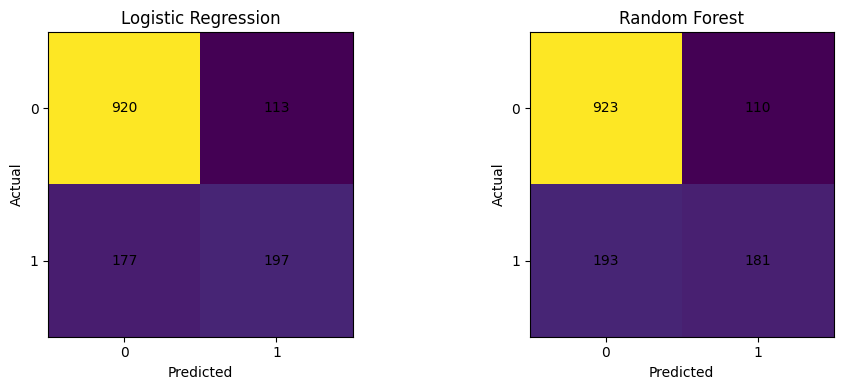

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

axes[0].imshow(log_cm)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, log_cm[i,j], ha="center", va="center")

axes[1].imshow(rf_cm)
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, rf_cm[i,j], ha="center", va="center")

plt.tight_layout()
plt.show()


### Model comparison

The two models are compared using Accuracy, Precision, Recall, F1-Score and the Confusion Matrix. In this run, Logistic Regression has the higher values for the four scalar metrics, so it is used for the sample prediction step.

## 8. Application: Sample Customer Predictions

In [ ]:
final_model = logistic_model

# Use real rows from the test set as sample customer inputs.
sample_customers = X_test.head(5).copy()
sample_predictions = final_model.predict(sample_customers)
sample_labels = np.where(sample_predictions == 1, "Churn", "No Churn")

prediction_output = sample_customers.copy()
prediction_output["Prediction"] = sample_labels

display(prediction_output[[
    "gender", "SeniorCitizen", "tenure", "Contract",
    "InternetService", "MonthlyCharges", "TotalCharges", "Prediction"
]])


,gender,SeniorCitizen,tenure,Contract,InternetService,MonthlyCharges,TotalCharges,Prediction
974,Female,0,59,Two year,DSL,75.95,4542.35,No Churn
619,Female,0,7,Month-to-month,Fiber optic,78.55,522.95,Churn
4289,Female,0,54,Two year,No,20.10,1079.45,No Churn
3721,Female,0,2,Month-to-month,No,20.65,38.70,No Churn
4533,Female,0,71,Two year,Fiber optic,105.15,7555.00,No Churn


## 9. Conclusion

This project completed the required customer churn machine-learning pipeline: data loading, understanding, cleaning, exploratory analysis, feature engineering, categorical encoding, train/test splitting, model training, evaluation, and sample prediction.

The main data-quality issue was the 11 blank `TotalCharges` entries. The `customerID` field was removed because it is an identifier rather than a behavioral feature.

For this experiment, Logistic Regression produced the stronger test-set results across Accuracy, Precision, Recall, and F1-Score, so it was used as the final prediction model.

A telecom company could use a churn model to identify customers who may be at higher risk of leaving and then investigate appropriate retention actions. However, model predictions are not guarantees: performance can change on future customer data, and business decisions should consider cost, fairness, data quality, and monitoring over time.


## Submission Information

- **Churn:** whether a customer leaves the company.
- **X:** input/customer features used by the model.
- **y:** target variable, encoded as 0 = No Churn and 1 = Churn.
- **One-hot encoding:** converts categorical values into numeric indicator columns.
- **Train/test split:** training data is used to learn patterns; test data checks performance on unseen records.
- **Accuracy:** proportion of all predictions that are correct.
- **Precision:** among customers predicted to churn, how many actually churned.
- **Recall:** among customers who actually churned, how many the model identified.
- **F1-score:** combines precision and recall into one metric.
- **Confusion matrix:** shows true/false positive and negative predictions.
